<a href="https://colab.research.google.com/github/Shubhranshu331/Adult-Income-prediction-model/blob/master/Predict_Adult_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💰 Adult Census Income Prediction
### Complete ML Pipeline Project — Google Colab (Free Azure ML Alternative)

---
**Goal:** Predict whether a person earns **>50K or <=50K** per year using census data.

**Dataset:** UCI Adult Census Income (1994 Census Bureau)

## 🗺️ Project Roadmap
```
Step 1 → Import Libraries
Step 2 → Load Dataset
Step 3 → Exploratory Data Analysis (EDA)
Step 4 → Data Preprocessing
Step 5 → Build ML Pipeline
Step 6 → Train the Model
Step 7 → Evaluate the Model
Step 8 → Save & Reload the Model
Step 9 → Predict on New Data
```
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported!')

✅ All libraries imported!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving adult.data to adult.data
Saving adult.test to adult.test


In [3]:
# Column names from adult.names
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
    'income'
]

# Load training data
train_df = pd.read_csv(
    'adult.data',
    names=column_names,
    sep=', ',
    engine='python',
    na_values='?'
)

# Load test data (skip header comment line)
test_df = pd.read_csv(
    'adult.test',
    names=column_names,
    sep=', ',
    engine='python',
    na_values='?',
    skiprows=1
)

# Clean trailing '.' in test labels
test_df['income'] = test_df['income'].str.replace('.', '', regex=False)

print(f'✅ Training set : {train_df.shape}  →  {train_df.shape[0]} rows, {train_df.shape[1]} columns')
print(f'✅ Test set     : {test_df.shape}  →  {test_df.shape[0]} rows, {test_df.shape[1]} columns')
train_df.head()

✅ Training set : (32561, 15)  →  32561 rows, 15 columns
✅ Test set     : (16281, 15)  →  16281 rows, 15 columns


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Check for missing values
print(train_df.isnull().sum())

# See target distribution
print(train_df['income'].value_counts())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [5]:
print('=== Dataset Info ===')
train_df.info()
print('\n=== First 5 rows ===')
train_df.head()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

=== First 5 rows ===


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
print('=== Numerical Features Summary ===')
train_df.describe()

=== Numerical Features Summary ===


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


=== Missing Values ===
                Missing Count  Missing %
workclass                1836       5.64
occupation               1843       5.66
native_country            583       1.79


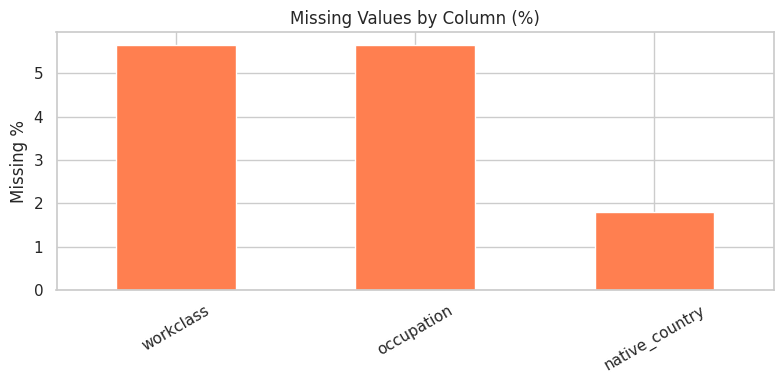

In [7]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== Missing Values ===')
print(missing_df)

# Visualize
if not missing_df.empty:
    missing_df['Missing %'].plot(kind='bar', color='coral', figsize=(8, 4))
    plt.title('Missing Values by Column (%)')
    plt.ylabel('Missing %')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found!')

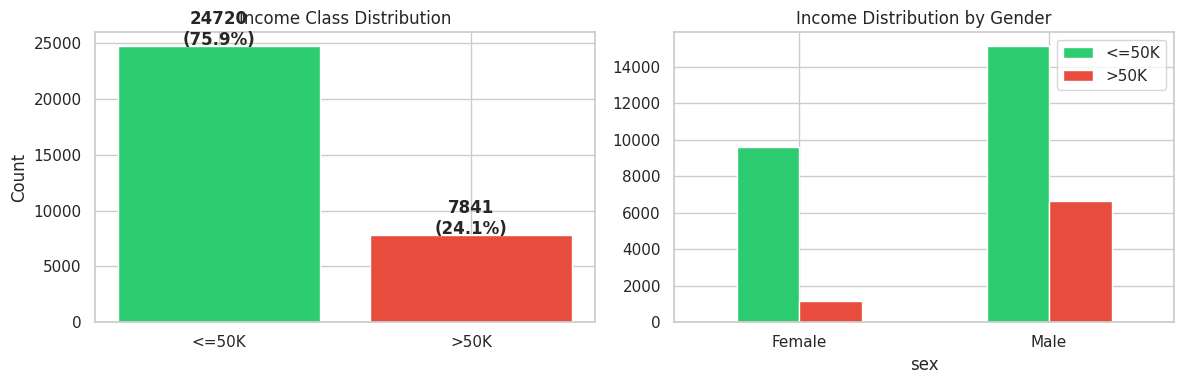

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train_df['income'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Income Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v}\n({v/len(train_df)*100:.1f}%)', ha='center', fontweight='bold')

# Income by gender
pd.crosstab(train_df['sex'], train_df['income']).plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Income Distribution by Gender')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['<=50K', '>50K'])

plt.tight_layout()
plt.show()

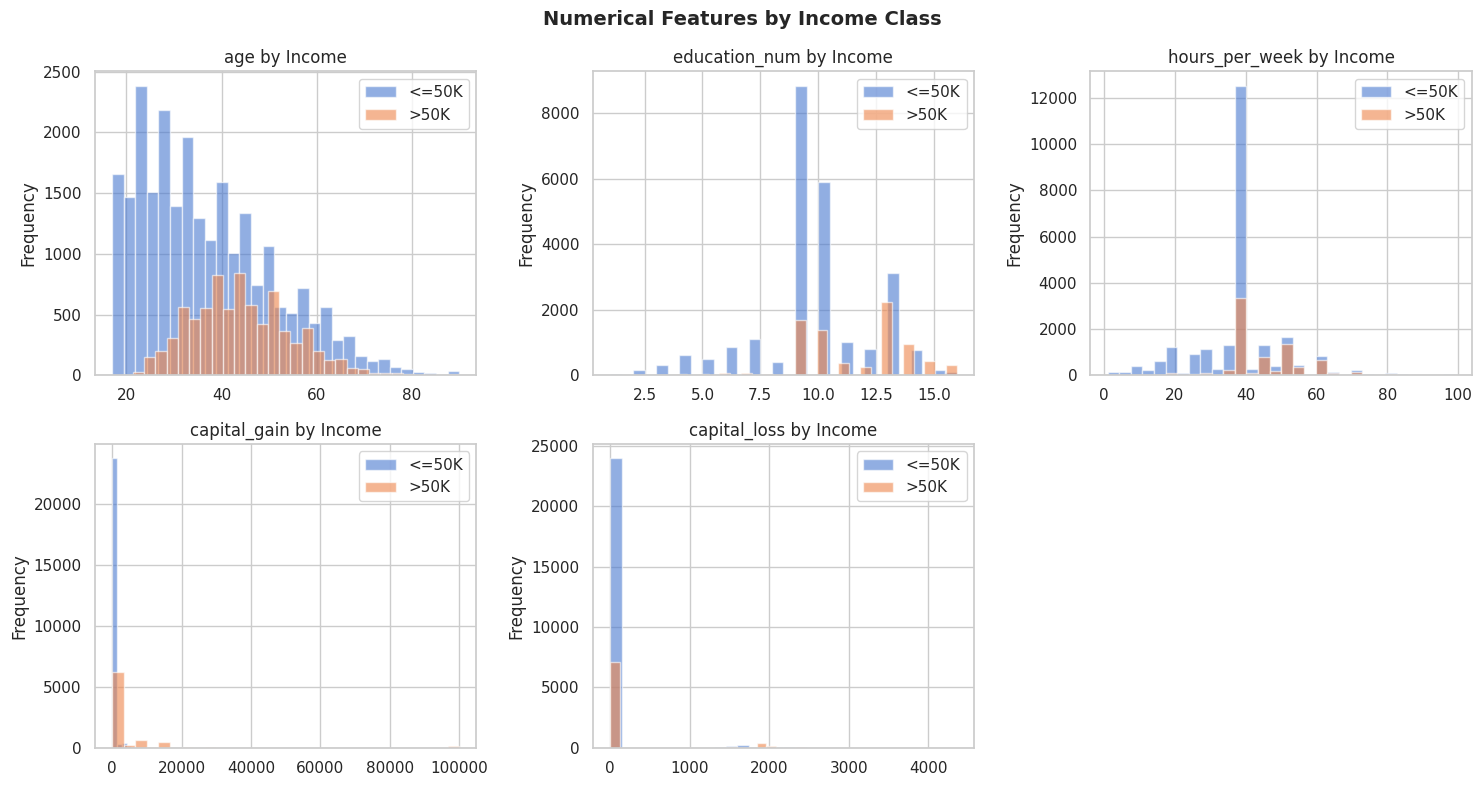

In [9]:
num_cols = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    train_df.groupby('income')[col].plot(
        kind='hist', alpha=0.6, bins=30, ax=axes[i], legend=True
    )
    axes[i].set_title(f'{col} by Income')
    axes[i].legend(['<=50K', '>50K'])

axes[-1].set_visible(False)
plt.suptitle('Numerical Features by Income Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

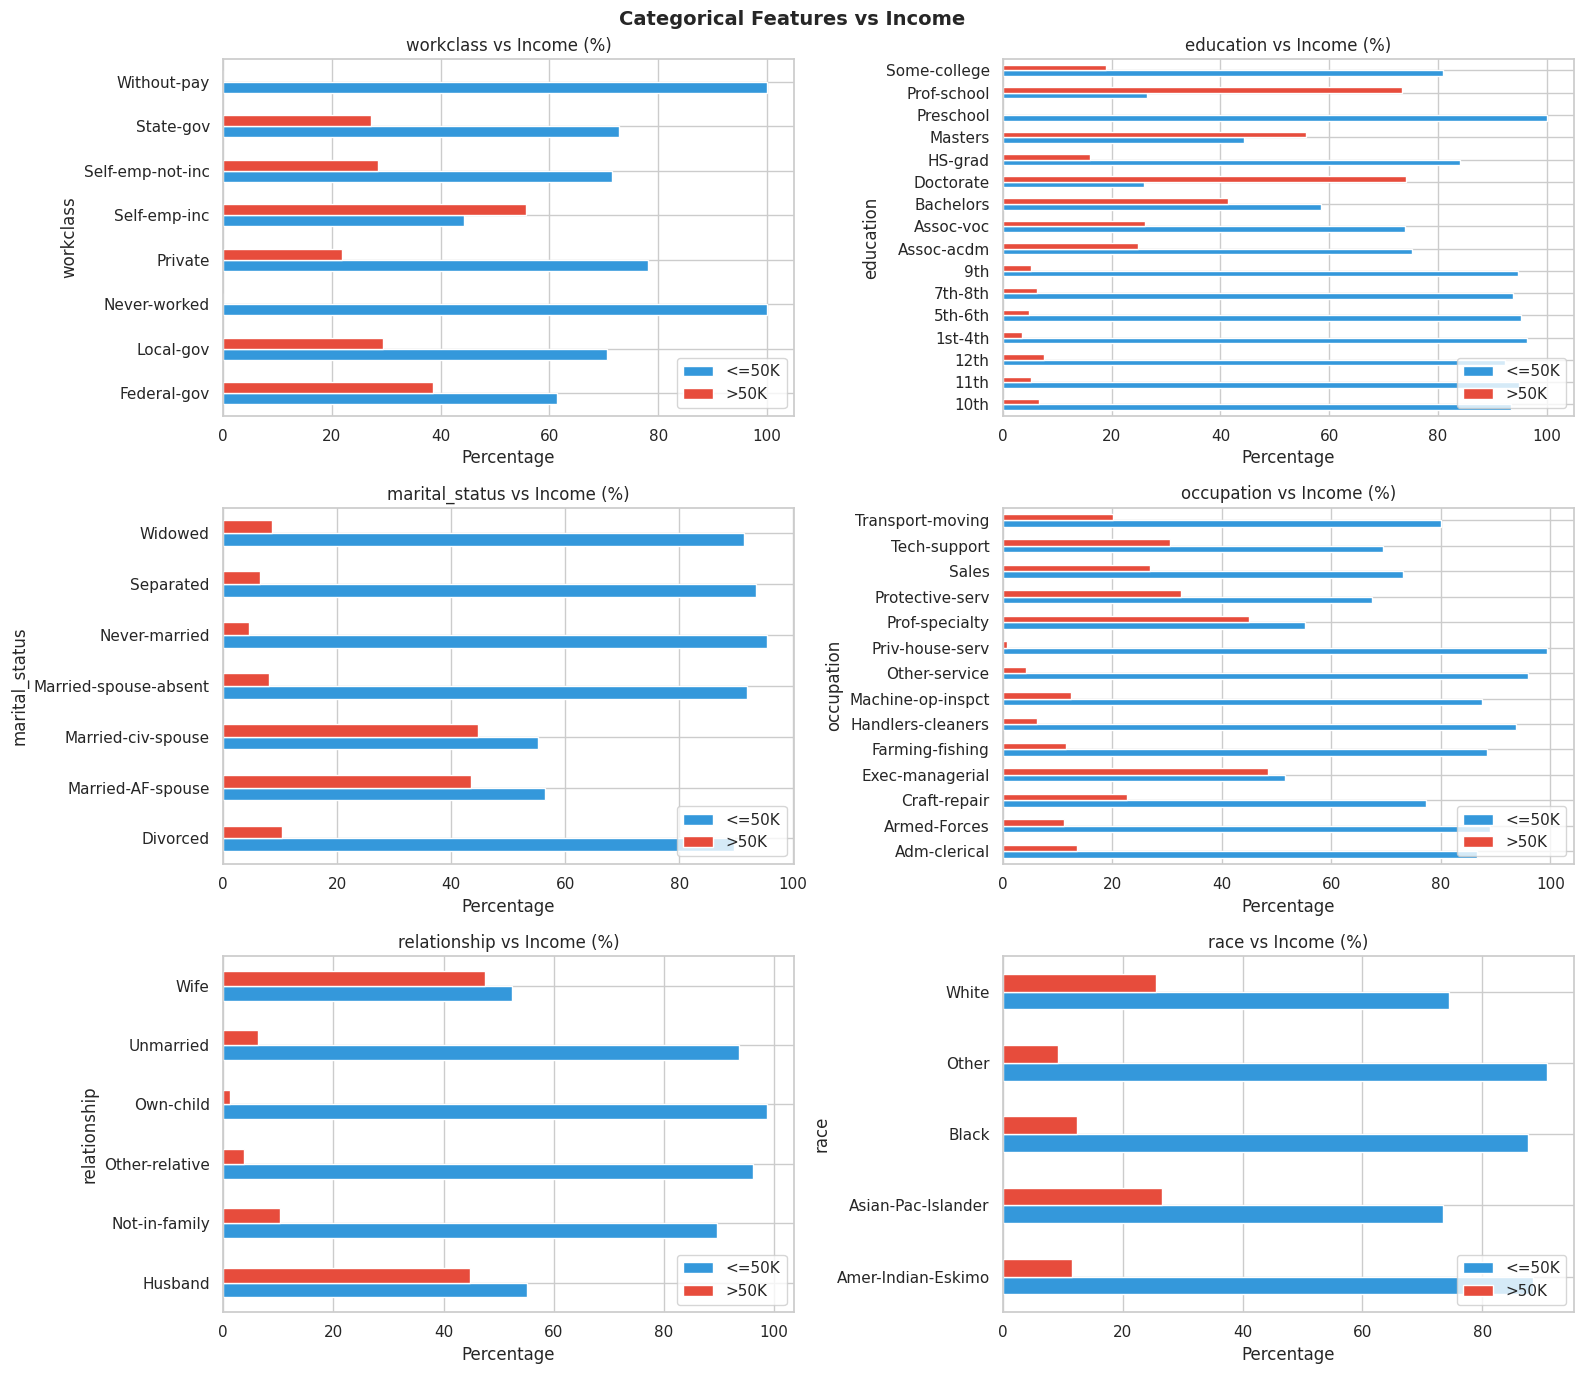

In [10]:
cat_cols = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train_df[col], train_df['income'], normalize='index') * 100
    ct.plot(kind='barh', ax=axes[i], color=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} vs Income (%)')
    axes[i].set_xlabel('Percentage')
    axes[i].legend(['<=50K', '>50K'], loc='lower right')

plt.suptitle('Categorical Features vs Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

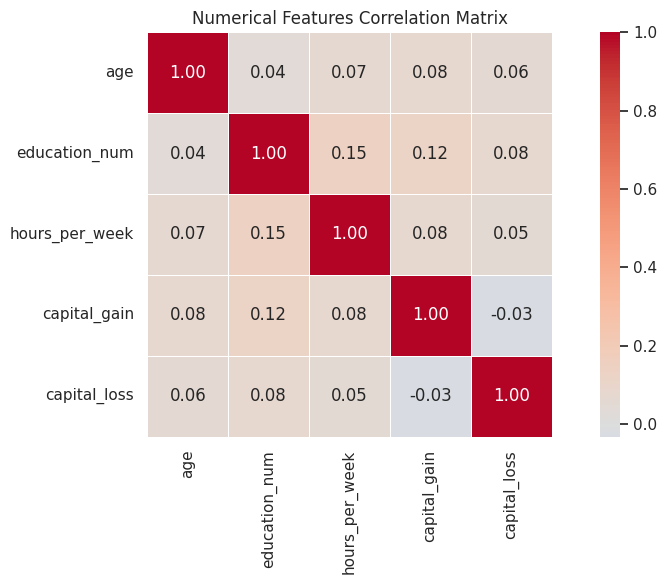

In [11]:
plt.figure(figsize=(10, 6))
corr = train_df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Numerical Features Correlation Matrix')
plt.tight_layout()
plt.show()

In [12]:
# <=50K → 0,  >50K → 1
label_map = {'<=50K': 0, '>50K': 1}

train_df['income'] = train_df['income'].map(label_map)
test_df['income']  = test_df['income'].map(label_map)

print('Target encoding:')
print(train_df['income'].value_counts())

Target encoding:
income
0    24720
1     7841
Name: count, dtype: int64


In [13]:
# --- 4.2 Drop 'fnlwgt' (survey weight — not useful for prediction) ---
train_df = train_df.drop('fnlwgt', axis=1)
test_df  = test_df.drop('fnlwgt', axis=1)

# --- 4.3 Separate Features & Target ---
X_train = train_df.drop('income', axis=1)
y_train = train_df['income']

X_test  = test_df.drop('income', axis=1)
y_test  = test_df['income']

# --- 4.4 Identify column types ---
numerical_cols   = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns   ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

Numerical columns   (5): ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical columns (8): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Train: (32561, 13) | Test: (16281, 13)


In [14]:
# --- Numerical Pipeline: Impute → Scale ---
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# --- Categorical Pipeline: Impute → One-Hot Encode ---
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Combine both using ColumnTransformer ---
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# --- Full Pipeline: Preprocessor + Classifier ---
ml_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
                        n_estimators=200,
                        max_depth=10,
                        min_samples_leaf=5,
                        random_state=42,
                        n_jobs=-1
                    ))
])

print('✅ ML Pipeline built!')
print('\nPipeline Steps:')
for name, step in ml_pipeline.steps:
    print(f'   → {name}: {step.__class__.__name__}')

✅ ML Pipeline built!

Pipeline Steps:
   → preprocessor: ColumnTransformer
   → classifier: RandomForestClassifier


In [15]:
print('🔄 Training the pipeline...')
ml_pipeline.fit(X_train, y_train)
print('✅ Training complete!\n')

# Cross-Validation (5-fold) on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ml_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f'📊 5-Fold Cross-Validation Accuracy:')
for i, score in enumerate(cv_scores):
    print(f'   Fold {i+1}: {score:.4f}')
print(f'   Mean : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

🔄 Training the pipeline...
✅ Training complete!

📊 5-Fold Cross-Validation Accuracy:
   Fold 1: 0.8592
   Fold 2: 0.8570
   Fold 3: 0.8543
   Fold 4: 0.8541
   Fold 5: 0.8570
   Mean : 0.8563 ± 0.0019


In [16]:
# --- 7.1 Predictions ---
y_pred       = ml_pipeline.predict(X_test)
y_pred_proba = ml_pipeline.predict_proba(X_test)[:, 1]

# --- 7.2 Metrics ---
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 50)
print(f'  ✅ Test Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  ✅ ROC-AUC Score  : {auc:.4f}')
print('=' * 50)
print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

  ✅ Test Accuracy  : 0.8565  (85.65%)
  ✅ ROC-AUC Score  : 0.9097

📋 Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.96      0.91     12435
        >50K       0.79      0.54      0.64      3846

    accuracy                           0.86     16281
   macro avg       0.83      0.75      0.77     16281
weighted avg       0.85      0.86      0.85     16281



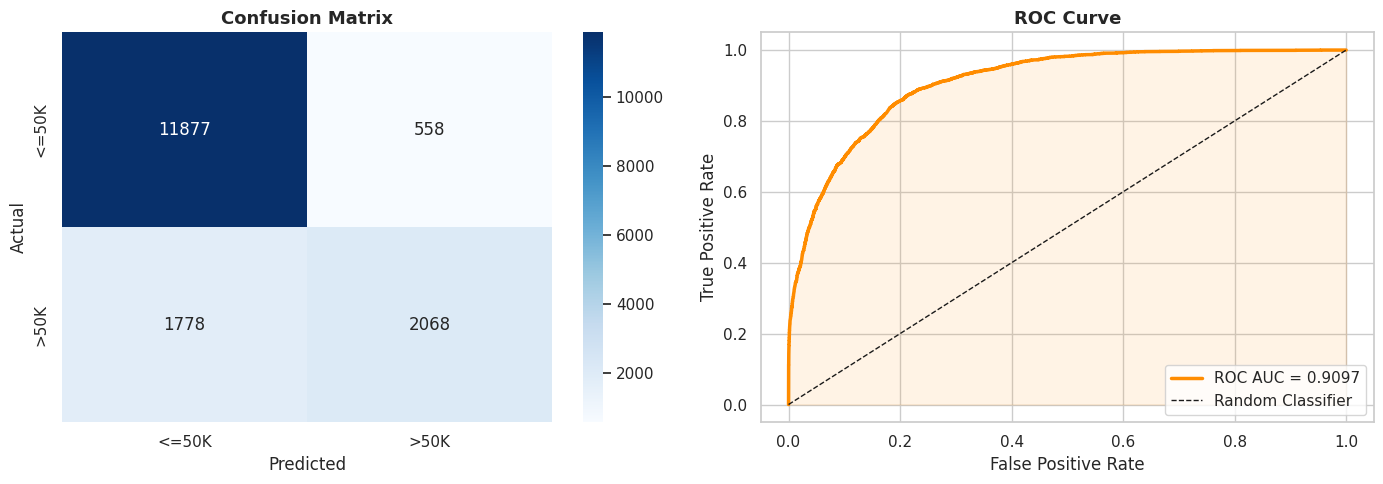

In [17]:
# --- 7.3 Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# --- 7.4 ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

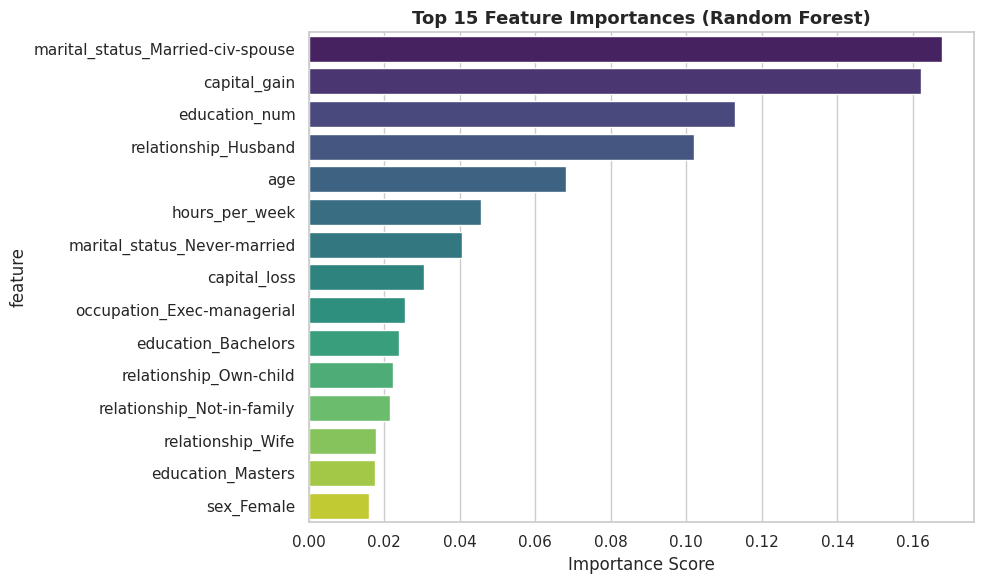

In [18]:
# --- 7.5 Feature Importance ---
rf_model = ml_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# Get feature names after encoding
ohe_features = ml_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names_out(categorical_cols).tolist()

all_features = numerical_cols + ohe_features

feat_df = pd.DataFrame({
    'feature':    all_features,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [19]:
# Save the entire pipeline (preprocessing + model)
model_path = 'adult_income_pipeline.pkl'
joblib.dump(ml_pipeline, model_path)
print(f'✅ Model saved as: {model_path}')

# Reload and verify
loaded_pipeline = joblib.load(model_path)
reload_acc = accuracy_score(y_test, loaded_pipeline.predict(X_test))
print(f'✅ Reloaded model accuracy: {reload_acc:.4f}  (should match above)')

# Download the model to your computer
files.download(model_path)
print('✅ Model downloaded to your computer!')

✅ Model saved as: adult_income_pipeline.pkl
✅ Reloaded model accuracy: 0.8565  (should match above)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded to your computer!


In [20]:
# Simulate a new person's data
new_person = pd.DataFrame([{
    'age':            35,
    'workclass':      'Private',
    'education':      'Bachelors',
    'education_num':  13,
    'marital_status': 'Married-civ-spouse',
    'occupation':     'Exec-managerial',
    'relationship':   'Husband',
    'race':           'White',
    'sex':            'Male',
    'capital_gain':   5000,
    'capital_loss':   0,
    'hours_per_week': 45,
    'native_country': 'United-States'
}])

# Predict
prediction = loaded_pipeline.predict(new_person)[0]
probability = loaded_pipeline.predict_proba(new_person)[0]

print('👤 New Person Prediction:')
print(f'   Income Prediction : {"💰 >50K" if prediction == 1 else "💵 <=50K"}')
print(f'   Probability <=50K : {probability[0]*100:.1f}%')
print(f'   Probability  >50K : {probability[1]*100:.1f}%')

👤 New Person Prediction:
   Income Prediction : 💰 >50K
   Probability <=50K : 33.2%
   Probability  >50K : 66.8%


In [21]:
# --- Batch Prediction on multiple people ---
batch = pd.DataFrame([
    {'age': 25, 'workclass': 'Private',      'education': 'HS-grad',    'education_num': 9,  'marital_status': 'Never-married',    'occupation': 'Machine-op-inspct', 'relationship': 'Own-child',  'race': 'Black', 'sex': 'Male',   'capital_gain': 0,    'capital_loss': 0, 'hours_per_week': 40, 'native_country': 'United-States'},
    {'age': 52, 'workclass': 'Self-emp-inc', 'education': 'Bachelors',  'education_num': 13, 'marital_status': 'Married-civ-spouse','occupation': 'Exec-managerial',   'relationship': 'Husband',    'race': 'White', 'sex': 'Male',   'capital_gain': 99999,'capital_loss': 0, 'hours_per_week': 60, 'native_country': 'United-States'},
    {'age': 44, 'workclass': 'Private',      'education': 'Masters',    'education_num': 14, 'marital_status': 'Divorced',          'occupation': 'Prof-specialty',    'relationship': 'Not-in-family','race': 'White','sex': 'Female','capital_gain': 0,    'capital_loss': 0, 'hours_per_week': 40, 'native_country': 'United-States'},
])

batch_preds = loaded_pipeline.predict(batch)
batch_proba = loaded_pipeline.predict_proba(batch)

print('\n📋 Batch Predictions:')
print(f'{"Person":<8} {"Prediction":<12} {"P(<=50K)":<12} {"P(>50K)"}')
print('-' * 45)
for i, (pred, prob) in enumerate(zip(batch_preds, batch_proba)):
    label = '>50K' if pred == 1 else '<=50K'
    print(f'Person {i+1}  {label:<12} {prob[0]*100:.1f}%        {prob[1]*100:.1f}%')


📋 Batch Predictions:
Person   Prediction   P(<=50K)     P(>50K)
---------------------------------------------
Person 1  <=50K        99.2%        0.8%
Person 2  >50K         9.5%        90.5%
Person 3  <=50K        81.9%        18.1%
